# LeetCode #30: Substring with Concatenation of All Words

https://leetcode.com/problems/substring-with-concatenation-of-all-words/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \cdot m \cdot k)$ | $O(m)$ |
| **Sliding Window + HashMap** ★ | $O(n \cdot m)$ | $O(m)$ |

---

## Understanding the Methods

### Brute Force
For each starting index in `s`, extract a substring of total length `wordLen * wordCount` and check if it's a valid concatenation using a frequency map. This is $O(n)$ starts × $O(m \cdot k)$ check = $O(n \cdot m \cdot k)$.

### Optimal: Sliding Window + HashMap ★
Key insight: all words have the same length `wordLen`. So only `wordLen` distinct word-boundary alignments exist (offsets 0 to wordLen-1). For each offset, run a **sliding window** that advances `wordLen` characters at a time:
- Maintain a `seen` frequency map and a `count` of matched words.
- When the current word is valid but over-counted, shrink the left side word by word.
- When `count == wordCount`, record the left index.

Each offset processes each character once: total $O(wordLen) \times O(n / wordLen) = O(n)$ per outer loop, giving $O(n \cdot wordLen)$ overall.

**Constraints:**
* $1 \leq$ s.length $\leq 10^4$
* $1 \leq$ words.length $\leq 5000$
* $1 \leq$ words[i].length $\leq 30$
* `s` and `words[i]` consist of lowercase English letters

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<int> FindSubstring(string s, string[] words) {
        var result = new List<int>();
        int n = s.Length, wLen = words[0].Length, wCount = words.Length;
        var freq = new Dictionary<string, int>();
        foreach (var w in words) freq[w] = freq.GetValueOrDefault(w) + 1;

        for (int off = 0; off < wLen; off++) {
            var seen = new Dictionary<string, int>();
            int left = off, count = 0;
            for (int right = off; right + wLen <= n; right += wLen) {
                string w = s.Substring(right, wLen);
                if (!freq.ContainsKey(w)) { seen.Clear(); count = 0; left = right + wLen; continue; }
                seen[w] = seen.GetValueOrDefault(w) + 1;
                count++;
                while (seen[w] > freq[w]) {
                    string lw = s.Substring(left, wLen);
                    seen[lw]--;
                    count--;
                    left += wLen;
                }
                if (count == wCount) result.Add(left);
            }
        }
        return result;
    }
}

### Python

In [ ]:
from typing import List
from collections import Counter

class Solution:
    def findSubstring(self, s: str, words: List[str]) -> List[int]:
        n, w_len, w_count = len(s), len(words[0]), len(words)
        freq = Counter(words)
        result = []

        for off in range(w_len):
            seen = Counter()
            left = off
            count = 0
            for right in range(off, n - w_len + 1, w_len):
                w = s[right:right + w_len]
                if w not in freq:
                    seen.clear()
                    count = 0
                    left = right + w_len
                    continue
                seen[w] += 1
                count += 1
                while seen[w] > freq[w]:
                    lw = s[left:left + w_len]
                    seen[lw] -= 1
                    count -= 1
                    left += w_len
                if count == w_count:
                    result.append(left)
        return result

### Go

In [ ]:
package main

func findSubstring(s string, words []string) []int {
	n, wLen, wCount := len(s), len(words[0]), len(words)
	freq := map[string]int{}
	for _, w := range words {
		freq[w]++
	}
	var result []int
	for off := 0; off < wLen; off++ {
		seen := map[string]int{}
		left, count := off, 0
		for right := off; right+wLen <= n; right += wLen {
			w := s[right : right+wLen]
			if _, ok := freq[w]; !ok {
				for k := range seen {
					delete(seen, k)
				}
				count = 0
				left = right + wLen
				continue
			}
			seen[w]++
			count++
			for seen[w] > freq[w] {
				lw := s[left : left+wLen]
				seen[lw]--
				count--
				left += wLen
			}
			if count == wCount {
				result = append(result, left)
			}
		}
	}
	return result
}

### Rust

In [ ]:
use std::collections::HashMap;

pub struct Solution;

impl Solution {
    pub fn find_substring(s: String, words: Vec<String>) -> Vec<i32> {
        let n = s.len();
        let w_len = words[0].len();
        let w_count = words.len();
        let s_bytes = s.as_bytes();
        let mut freq: HashMap<&[u8], i32> = HashMap::new();
        for w in &words {
            *freq.entry(w.as_bytes()).or_insert(0) += 1;
        }
        let mut result = Vec::new();
        for off in 0..w_len {
            let mut seen: HashMap<&[u8], i32> = HashMap::new();
            let mut left = off;
            let mut count = 0i32;
            let mut right = off;
            while right + w_len <= n {
                let w = &s_bytes[right..right + w_len];
                if !freq.contains_key(w) {
                    seen.clear();
                    count = 0;
                    left = right + w_len;
                } else {
                    *seen.entry(w).or_insert(0) += 1;
                    count += 1;
                    while seen[w] > freq[w] {
                        let lw = &s_bytes[left..left + w_len];
                        *seen.get_mut(lw).unwrap() -= 1;
                        count -= 1;
                        left += w_len;
                    }
                    if count == w_count as i32 {
                        result.push(left as i32);
                    }
                }
                right += w_len;
            }
        }
        result
    }
}

## Example Scenarios

### 1. Common Case — Two Words, Multiple Matches
**Input:** s = `"barfoothefoobarman"`, words = `["foo","bar"]`
wordLen = 3, totalLen = 6. At offset 0: window "barfoo" → bar ✓, foo ✓ → match. Slide: "foothe" → "the" not in map → shrink. At offset 9: "foobar" → foo ✓, bar ✓ → match.
**Why tricky:** The sliding window adds one word and possibly shrinks from the left. This basic case verifies the expand/shrink mechanics.

**Output:** `[0, 9]`

### 2. Slightly Complex — Duplicate Words Requiring Exact Counts
**Input:** s = `"wordgoodgoodgoodbestword"`, words = `["word","good","best","word"]`
"word" appears twice in words[]. At every starting position, the window either has too many "good"s or only one "word" — never the exact count {word:2, good:1, best:1}.
**Why tricky:** HashMap must track *exact* frequency counts, not just presence. A set-based approach would incorrectly report matches.

**Output:** `[]` — no valid concatenation.

### 3. Edge Case: Time Factor — All Same Single-Char Words (n = 10⁴)
**Input:** s = `"aaa...a"` (n = 10⁴), words = `["a","a",...,"a"]` (5000 copies)
wordLen = 1, so only 1 offset to process. The sliding window scans once left-to-right, adding/removing one word per step → $O(n)$.
**Why tricky:** Brute force would be $O(n \cdot m \cdot k) \approx 5 \times 10^7$. The sliding window collapses to $O(n)$ because wordLen = 1 means a single offset. Tests maximum throughput.

**Output:** `[0, 1, ..., 5000]` — 5001 valid starting positions.

### 4. Edge Case: Space Factor — Many Unique Words, No Match
**Input:** s has length 10⁴, words = 5000 unique 2-char words
Both the reference HashMap (5000 entries) and the sliding-window HashMap (up to 5000 entries) fill to capacity. Total space: $O(m)$ where $m = 5000$.
**Why tricky:** Maximum HashMap memory is consumed regardless of whether any match exists. When no match is found, space is fully allocated but wasted. Interviewers check: does your solution degrade gracefully?

**Output:** `[]` — both HashMaps at full capacity, zero matches.

### 5. Almost-Impossible but Plausible — Single Word (Degenerates to strStr)
**Input:** s = `"aaaa"`, words = `["aa"]`
wordLen = 2, wordCount = 1, totalLen = 2. Check every offset (0 and 1): offset 0 → "aa" at pos 0 ✓, "aa" at pos 2 ✓ (but only need 1). Offset 1 → "aa" at pos 1 ✓.
**Why tricky:** With a single word, the problem reduces to finding all occurrences. Overlapping matches are valid — indices 0, 1, and 2 all produce the substring "aa".

**Output:** `[0, 1, 2]`

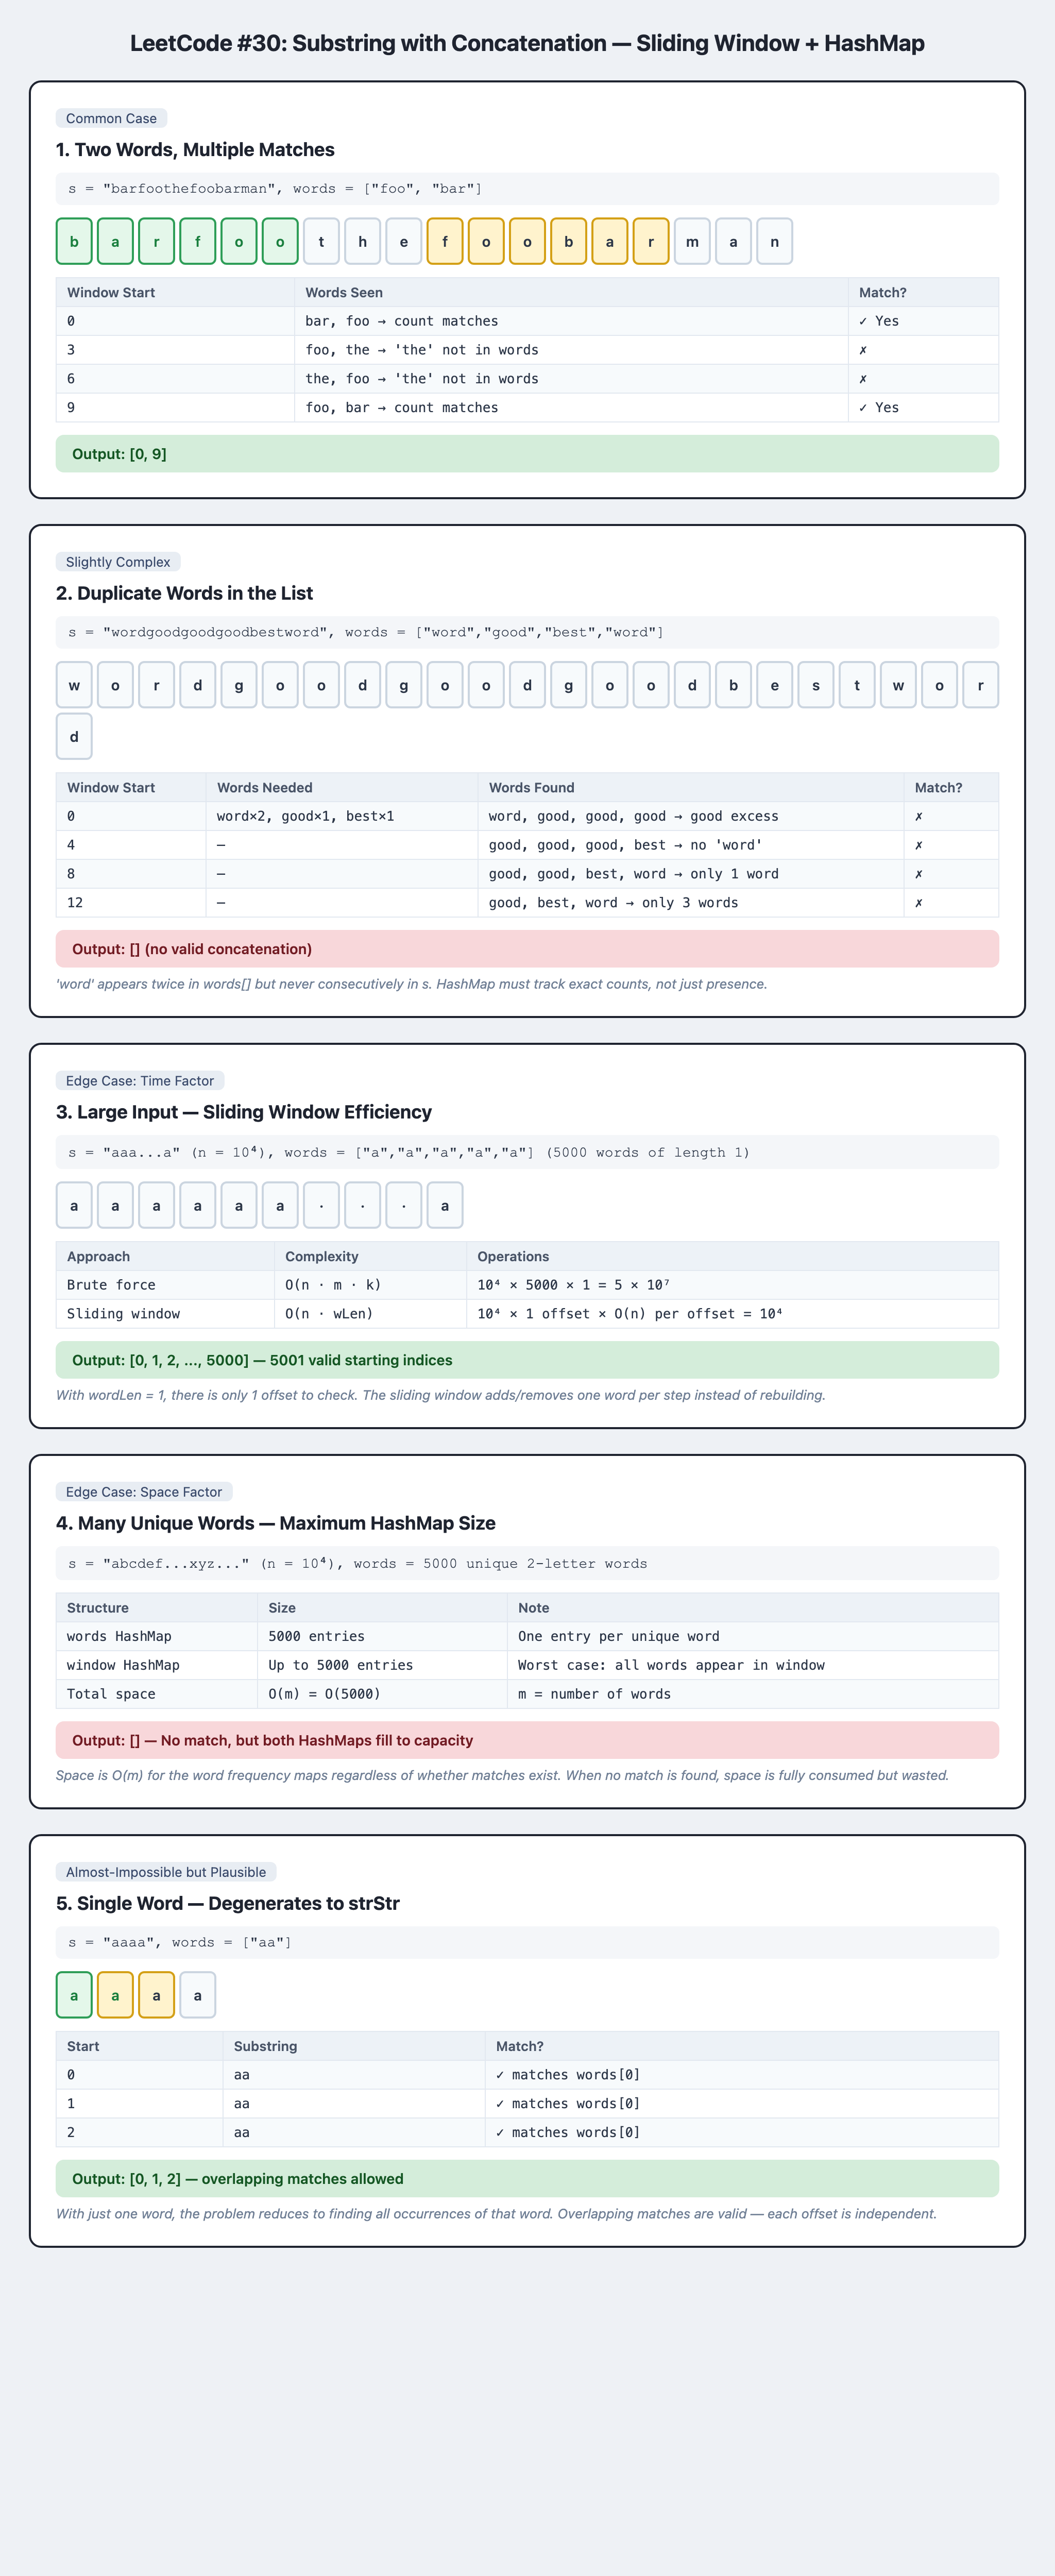